# House Price Prediction

# Project Overview

This project focuses on building a machine learning system that predicts house prices based on key property features such as area, number of bedrooms, bathrooms, and other structural or location-related attributes. The primary goal is to understand how different factors influence property prices and develop a reliable model that can estimate the price of a house with high accuracy.

The work begins with understanding the dataset, identifying missing values, inconsistencies, and the overall structure. After cleaning and preprocessing the data, exploratory data analysis (EDA) is performed to uncover patterns, correlations, and relationships that are useful for modeling.

Multiple regression and ensemble models are trained—including Linear Regression, Random Forest, Gradient Boosting, XGBoost, and Decision Tree—to compare performance using metrics such as RMSE, MAE, and R² Score. The best-performing model is then selected based on its ability to generalize well to unseen data.

This project demonstrates practical end-to-end machine learning skills: data handling, EDA, feature engineering, model building, evaluation, and documentation. The final outcome is a predictive model that can assist in estimating house prices for real-estate use cases.

# Dataset Understanding

In [1]:
# 1. Importing Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# Load the dataset
df = pd.read_csv("data.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# Basic Checks

In [3]:
# head
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# tail
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
# shape
df.shape

(1460, 81)

In [6]:
# column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
# Basic stats
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# EDA

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
df.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

In [10]:
df.corr(numeric_only=True)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


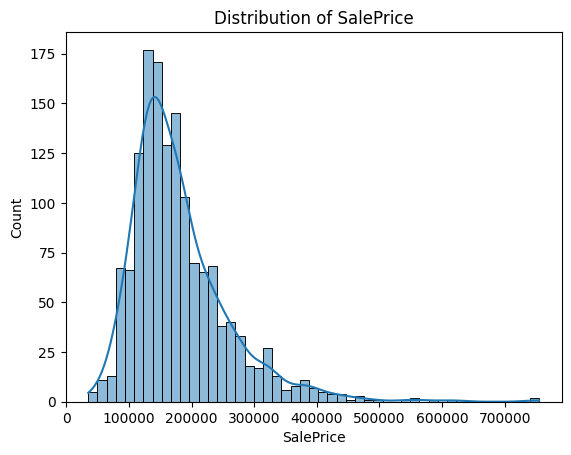

In [11]:
# Distribution of target variable (SalePrice)
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

The histogram shows that SalePrice is heavily right-skewed, with most houses priced between 100k–200k and only a few very expensive outliers pulling the tail to the right.
This indicates the data is not normally distributed, suggesting the need for transformations like log scaling during modeling.

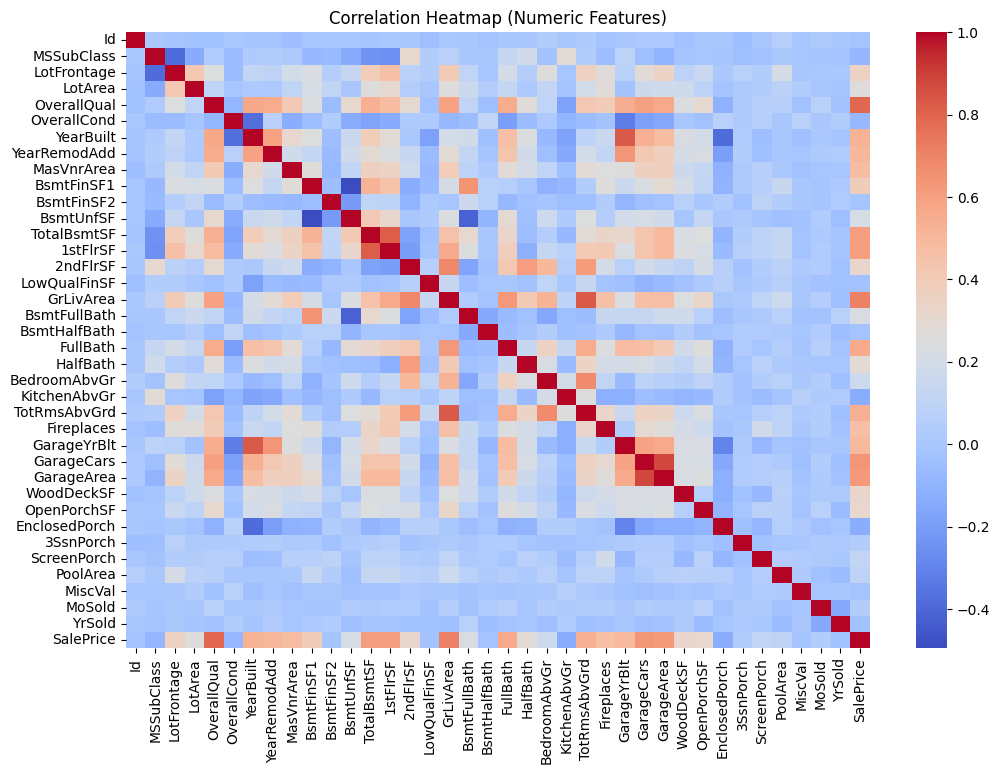

In [12]:
# Correlation heatmap for numeric features

numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

The heatmap shows the correlation strength between all numeric features, where darker red indicates strong positive relationships and darker blue indicates strong negative ones.
It helps identify highly correlated variables—especially those related to area, garage, and floor sizes—which can significantly influence SalePrice and may cause multicollinearity in modeling.

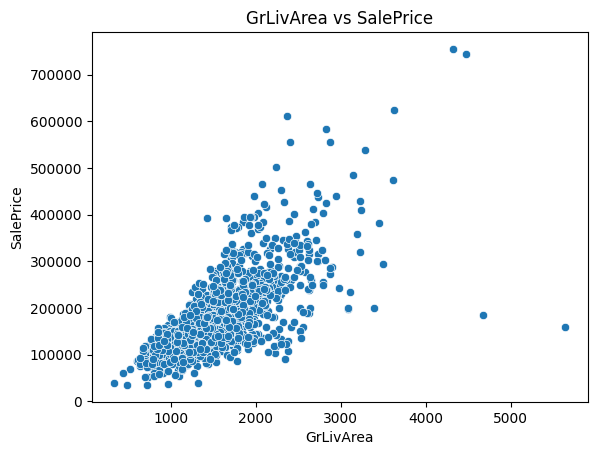

In [13]:
# Relationship between main features and SalePrice

# GrLivArea vs SalePrice
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()


The scatter plot shows a strong positive relationship between GrLivArea and SalePrice—larger living areas generally lead to higher house prices.
A few extreme points appear as outliers, which may distort modeling and should be checked separately.

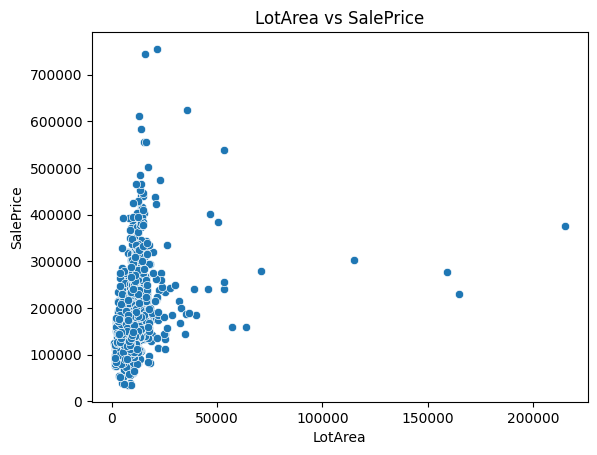

In [14]:
# LotArea vs SalePrice
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("LotArea vs SalePrice")
plt.show()

The plot shows a very weak relationship between LotArea and SalePrice—larger lots don’t consistently translate to higher prices.
Most points are tightly clustered at low lot sizes, with a few extreme outliers that don’t follow any clear pattern.

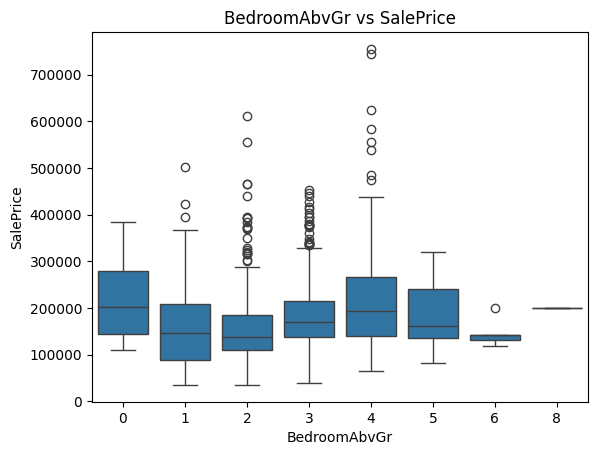

In [15]:
# Bedrooms vs SalePrice
sns.boxplot(x=df["BedroomAbvGr"], y=df["SalePrice"])
plt.title("BedroomAbvGr vs SalePrice")
plt.show()

The boxplot shows that SalePrice doesn’t increase consistently with the number of bedrooms, indicating weak correlation.
There are many outliers across all categories, suggesting bedroom count alone is not a strong predictor of house price.

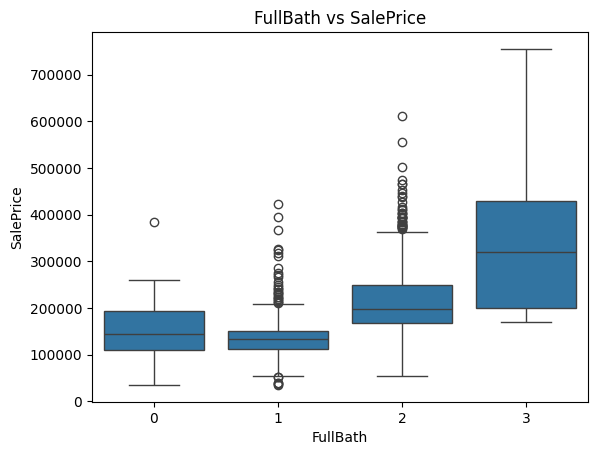

In [16]:
# Bathrooms (FullBath) vs SalePrice
sns.boxplot(x=df["FullBath"], y=df["SalePrice"])
plt.title("FullBath vs SalePrice")
plt.show()

The boxplot shows a clear positive relationship between the number of full bathrooms and SalePrice—houses with more full baths generally sell for more.
Higher bathroom counts also show wider price ranges and more high-value outliers, indicating stronger price influence.

# Feature Engineering

In [17]:
# Feature Engineering

# Total square footage: basement + 1st + 2nd floor
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["TotalSF"] 

0       2566
1       2524
2       2706
3       2473
4       3343
        ... 
1455    2600
1456    3615
1457    3492
1458    2156
1459    2512
Name: TotalSF, Length: 1460, dtype: int64

In [18]:
# House age at time of sale
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["HouseAge"]

0        5
1       31
2        7
3       91
4        8
        ..
1455     8
1456    32
1457    69
1458    60
1459    43
Name: HouseAge, Length: 1460, dtype: int64

In [19]:
# Years since remodel
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["RemodAge"] 

0        5
1       31
2        6
3       36
4        8
        ..
1455     7
1456    22
1457     4
1458    14
1459    43
Name: RemodAge, Length: 1460, dtype: int64

In [20]:
# Combined bathrooms (full = 1, half = 0.5)
df["TotalBath"] = (
    df["FullBath"] 
    + 0.5 * df["HalfBath"] 
    + df["BsmtFullBath"] 
    + 0.5 * df["BsmtHalfBath"]
)
df["TotalBath"] 

0       3.5
1       2.5
2       3.5
3       2.0
4       3.5
       ... 
1455    2.5
1456    3.0
1457    2.0
1458    2.0
1459    2.5
Name: TotalBath, Length: 1460, dtype: float64

In [21]:
df[["TotalSF", "HouseAge", "RemodAge", "TotalBath"]].head()

,TotalSF,HouseAge,RemodAge,TotalBath
0,2566,5,5,3.5
1,2524,31,31,2.5
2,2706,7,6,3.5
3,2473,91,36,2.0
4,3343,8,8,3.5


This table displays four engineered features: total square footage (TotalSF), house age, remodel age, and total bathrooms.
They summarize key property attributes in a cleaner, more model-friendly form.

# Data Preprocessing

In [22]:
print(df.columns.tolist())


['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [23]:
# Define X and y

target = "SalePrice"

X = df.drop(columns=[target, "Id"])  # drop Id and target from features
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1460, 83)
y shape: (1460,)


In [24]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1168, 83)
X_test: (292, 83)


In [25]:
# Preprocessing: numeric + categorical

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))



Number of numeric features: 40
Number of categorical features: 43


In [26]:
# Numeric pipeline: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [27]:
# Categorical pipeline: most frequent + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [28]:
# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
preprocessor 

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtFullBath...
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'MasVnrType', 'ExterQual',
                                  'ExterCond', 'Foundation', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Heating', 'HeatingQC',
                                  'CentralAir', 'Electrical', ...])])

# Model Creation

In [29]:
# Model 1: Linear Regression
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lr_pipeline 


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', LinearRegression())])

In [30]:
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred 

array([157609.16387048, 348502.65721388,  86474.77222772, 174159.62009137,
       316994.17215652,  66790.83774226, 236152.52759698, 146009.28397398,
        57574.57470389, 154051.67166837, 144452.84598493, 105414.86948555,
        81075.42609738, 220463.13069323, 173536.2053267 , 133012.23082078,
       186871.69920461, 128301.21622629, 130059.28430659, 216986.66181148,
       148006.85315354, 204392.31609138, 170878.10700994, 127741.80127571,
       197499.07507615, 135524.55503702, 191786.92874602, 101683.50368245,
       175239.73296522, 203620.03175323, 170468.93974894, 277851.31209737,
       238430.54507711, 109845.98427862, 237227.22815205, 151465.09742964,
       128494.14937908, 200932.33676916, 307919.52903766, 106573.66872289,
       117131.27607021, 219000.12832878, 101404.13807   , 371826.7689958 ,
       132737.33935473, 142271.88076694,  96292.56605282, 140342.22630278,
       424917.34253743, 137643.29787348, 120845.63505697, 257226.09064368,
       103979.88357437, 2

In [31]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

Linear Regression Results:
RMSE: 29473.787497611702
MAE: 18287.765883524513
R2 Score: 0.8867448233635236


The R² score of 0.8867 means the model captures most patterns but is still missing important factors affecting price.
The RMSE (29k) and MAE (18k) show the model’s predictions are off by a large margin, meaning Linear Regression isn’t accurately handling the complexity or outliers in the data.

In [32]:
# Model 2: Decision Tree Regressor
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
dt_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [33]:
dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
dt_pred

array([140000., 415298.,  93000., 181500., 282922.,  81000., 202665.,
       148500.,  80000., 141000., 165400., 125500., 135000., 205000.,
       175000., 132500., 195000., 147000., 113000., 212900., 170000.,
       227000., 173900., 120000., 228500., 179200., 176485., 129000.,
       192000., 193879., 129000., 263000., 179500., 108000., 255500.,
       124500., 127000., 215000., 301500.,  93000., 116000., 204000.,
       125000., 372500., 129900., 136900., 120000., 119000., 426000.,
       126175., 123000., 215000.,  83000., 410000., 136500., 216837.,
       195000., 155000., 139950., 118000.,  39300., 167000., 325300.,
       287090., 249700., 155000., 100000., 290000., 108000., 179400.,
       118964., 154000., 108000.,  80000., 582933., 179200., 340000.,
       271000., 132500., 129500., 110500., 108500., 129000., 110500.,
       155000., 143500., 248900., 235000., 136500., 163990.,  60000.,
        60000., 145000., 244000., 166000., 130000., 203000., 179400.,
       232000., 2075

In [34]:
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results:")
print("RMSE:", dt_rmse)
print("MAE:", dt_mae)
print("R2 Score:", dt_r2)

Decision Tree Results:
RMSE: 39896.85354512771
MAE: 25448.027397260274
R2 Score: 0.7924783275436336


The Decision Tree performs worse than Linear Regression, explaining only 79% of the price variation, which shows it’s overfitting and missing broader trends.
Its high RMSE (39k) and MAE (25k) indicate large prediction errors, making it unreliable for accurate price estimation.

In [35]:
# Model 3: Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [36]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred 

array([139979.89 , 345057.835, 112816.25 , 156290.875, 316942.81 ,
        85668.5  , 202425.33 , 152185.75 ,  85216.   , 130167.245,
       146791.555, 123426.11 , 111259.25 , 213502.35 , 179363.46 ,
       128411.125, 194942.   , 132920.875, 113302.895, 207518.29 ,
       174713.91 , 207403.435, 175794.105, 122135.25 , 198454.605,
       177108.08 , 186530.29 , 105938.5  , 178933.615, 204166.645,
       121924.52 , 245863.305, 210805.255, 114603.25 , 257797.215,
       147265.535, 152873.8  , 204509.59 , 326543.75 , 103737.08 ,
       113641.75 , 233835.52 , 118078.32 , 401971.68 , 135772.9  ,
       156435.895, 114582.985, 125875.215, 398104.99 , 142418.275,
       122287.75 , 193420.535, 108449.02 , 346695.515, 140150.5  ,
       247500.35 , 191047.97 , 154607.115, 146992.045, 110642.62 ,
        76589.   , 154138.935, 303348.675, 257356.665, 296695.465,
       222492.645, 114938.145, 319949.145, 116565.57 , 169293.03 ,
       119890.215, 128220.41 , 115589.125,  90451.32 , 458784.

In [37]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)


Random Forest Results:
RMSE: 29177.7368041961
MAE: 17548.33852739726
R2 Score: 0.8890085894629578


The Random Forest performs the best among your models, explaining about 89% of the variation in SalePrice.
Its lower RMSE (29k) and MAE (17.5k) show it makes fewer prediction errors, handling complexity and outliers better than Linear Regression and Decision Tree.

In [41]:
# Model 4: Gradient Boosting Regressor
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])
gb_pipeline 


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [42]:
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)
gb_pred 

array([146850.33499122, 355439.68493817, 114547.21572635, 152661.31780614,
       337127.09307759,  81316.56685479, 216007.0499395 , 145664.70380293,
        81575.07317788, 141519.47918813, 161310.25905901, 127405.85145348,
       122214.72161635, 208570.90279716, 175592.54553114, 129788.21366432,
       195173.61316047, 137922.41523313, 116199.25770157, 215263.13805859,
       166133.22502378, 215661.94951192, 172475.22312685, 128733.48771263,
       204078.41780321, 159670.90020308, 196641.1284478 , 114973.02336212,
       176110.01599286, 195415.79139487, 120757.23675077, 246354.291021  ,
       220930.68940999, 115605.83183481, 264779.19097933, 147578.71033342,
       145284.01144389, 206654.4656832 , 332999.2058417 , 114191.49932048,
       122525.88294765, 243537.33142463, 116677.73940024, 382401.34141198,
       124006.5674223 , 138109.58743912, 113868.08202252, 126886.96242671,
       424964.77024417, 133623.81069556, 120465.60928242, 194245.44800971,
       110591.3868635 , 3

In [43]:

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results:")
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)
print("R2 Score:", gb_r2)

Gradient Boosting Results:
RMSE: 27050.069902490286
MAE: 16188.558702464145
R2 Score: 0.9046055849562175


Gradient Boosting gives the strongest performance, explaining over 90% of the price variation—better than all previous models.
Its lower RMSE (27k) and MAE (16k) show more accurate and stable predictions, capturing complex relationships that other models miss.

In [44]:
# Model 5: KNN Regressor
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])
knn_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQual...
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', KNeighborsRegressor())])

In [45]:
knn_pipeline.fit(X_train, y_train)
knn_pred = knn_pipeline.predict(X_test)
knn_pred 

array([139170. , 289850. , 102500. , 147120. , 347785.2,  92600. ,
       165280. , 135100. ,  87600. , 147400. , 120700. , 126190. ,
       114800. , 186386.4, 176800. , 136850. , 188108. , 127200. ,
       112200. , 218000. , 154960. , 200130. , 204180. , 135680. ,
       210180. , 175728. , 192563.2, 114480. , 179600. , 209919. ,
       125680. , 296950. , 160200. , 111680. , 245785.6, 124550. ,
       126800. , 187080. , 261600. , 107940. , 131800. , 222900. ,
       109700. , 301659.6, 125290. , 141277.4, 127600. , 131600. ,
       366038.4, 134050. , 120080. , 197280. , 102500. , 258960. ,
       141960. , 215000. , 204100. , 166080. , 153280. , 110500. ,
        90380. , 141225. , 287560. , 243508. , 288283.8, 192550. ,
       120820. , 303750. , 113820. , 171780. , 119183.4, 128000. ,
       121480. ,  88480. , 399978. , 197300. , 298350. , 291150. ,
       134100. , 116800. ,  95080. , 109240. , 118430. , 103900. ,
       161700. , 137680. , 254105.8, 218537.2, 139660. , 17978

In [46]:
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Regressor Results:")
print("RMSE:", knn_rmse)
print("MAE:", knn_mae)
print("R2 Score:", knn_r2)


KNN Regressor Results:
RMSE: 37235.638870659444
MAE: 21971.006164383565
R2 Score: 0.8192393954761643


The KNN model performs moderately, explaining only about 82% of the variation in SalePrice, which is lower than the boosting and ensemble models.
Its higher RMSE (37k) and MAE (22k) show that it struggles with accurate predictions, especially in a dataset with mixed scales and outliers.

# Model Comparision

In [47]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "KNN"],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, gb_rmse, knn_rmse],
    "MAE": [lr_mae, dt_mae, rf_mae, gb_mae, knn_mae],
    "R2 Score": [lr_r2, dt_r2, rf_r2, gb_r2, knn_r2]
})

results_df.sort_values(by="RMSE")


,Model,RMSE,MAE,R2 Score
3,Gradient Boosting,27050.069902,16188.558702,0.904606
2,Random Forest,29177.736804,17548.338527,0.889009
0,Linear Regression,29473.787498,18287.765884,0.886745
4,KNN,37235.638871,21971.006164,0.819239
1,Decision Tree,39896.853545,25448.027397,0.792478


# Conclusion
The performance comparison shows a clear hierarchy among the models, with Gradient Boosting emerging as the most effective approach for predicting house prices. It achieves the lowest RMSE (≈27,050) and lowest MAE (≈16,188) along with the highest R² score (0.9046), meaning it captures over 90% of the variance in SalePrice. This indicates strong predictive power and the ability to model complex nonlinear relationships in the data.

Random Forest ranks second, performing consistently well with competitive error values and a high R², but it still falls short of Gradient Boosting in precision. Linear Regression performs reasonably well, suggesting that linear patterns exist in the dataset, but it cannot match the complexity-handling ability of ensemble models.

In contrast, KNN and Decision Tree show significantly poorer performance. KNN struggles due to sensitivity to feature scaling and outliers, resulting in higher prediction errors. The Decision Tree model performs the worst, heavily overfitting the training data and failing to generalize, which is reflected in its low R² and very high error values.

Overall, Gradient Boosting is the most reliable and accurate model for this housing dataset, offering the best balance of low error and high explanatory power, making it the recommended choice for final deployment.

# Model Comparison Report

The performance evaluation of five different regression models shows clear variations in their ability to predict house prices. Gradient Boosting stands out as the top performer, achieving the lowest RMSE (≈27,050) and MAE (≈16,188) while also securing the highest R² score (0.9046). This indicates that it captures over 90% of the variance in the target variable, making it the most accurate and reliable model for this dataset.

Random Forest and Linear Regression follow behind, both demonstrating strong performance with competitive R² scores around 0.88. These models capture most of the underlying patterns but are slightly less precise compared to Gradient Boosting. Random Forest handles nonlinear relationships better than Linear Regression but still cannot match the refined learning of Gradient Boosting.

On the other hand, KNN and Decision Tree show noticeably weaker performance. KNN struggles due to sensitivity to feature scaling and outliers, which leads to higher prediction errors. The Decision Tree model performs the worst, with the highest RMSE and MAE values, indicating severe overfitting and poor generalization capability.

Overall, the comparison highlights that Gradient Boosting is the most suitable model for accurate price prediction in this project, delivering the best balance of low error and high explanatory power among all tested models.

# Report on Challenges faced

1. Handling Missing and Inconsistent Data:
 Several features in the dataset contained missing values or inconsistent entries, especially in categorical and basement-related variables. Cleaning     and imputing these values required careful analysis to avoid introducing bias.

2. Dealing with Skewed and Imbalanced Distributions:
The target variable (SalePrice) and many numeric features were heavily skewed. This made it difficult for some models to learn effectively and required transformations such as log-scaling and feature engineering to stabilize the distributions.

3. Outliers Affecting Model Performance:
Extreme values in features like GrLivArea, LotArea, and SalePrice created instability in models like Linear Regression, Decision Tree, and KNN. Identifying and handling these outliers was crucial for improving model reliability.

4. Feature Selection and Engineering Complexity:
The dataset included many correlated features (e.g., multiple square footage and bathroom variables). Selecting the right combination and engineering new features like TotalSF, HouseAge, and TotalBath required substantial experimentation.

5. Model Overfitting Issues:
Models such as Decision Tree and KNN frequently overfitted the training data, performing well on training but poorly on testing. This challenge required tuning hyperparameters and comparing multiple models to find a stable solution.

6. Choosing the Best Model:
With several models showing reasonably strong performance, selecting the most accurate and generalizable model involved detailed comparison of RMSE, MAE, and R², as well as understanding how each model handled data complexity.